# Phase 7: Classifier Model Inference Test

This notebook verifies model prediction capabilities by running batch inferences on randomly selected offline validation samples and rendering visual classification overlays.

In [1]:
# Setup paths and imports
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image
import random

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'ai' and PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'ai'
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils

In [2]:
# Load accelerator and weights
device = utils.device.get_device()

def build_classifier(num_classes):
    model = models.efficientnet_b0()
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_classifier(utils.config.NUM_CLASSES).to(device)

if utils.config.BEST_MODEL_PATH.exists():
    checkpoint = torch.load(str(utils.config.BEST_MODEL_PATH), map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded model weights successfully.")
else:
    print("⚠️ Warning: Model weights not found. Predictions will be random.")

✅ Loaded model weights successfully.


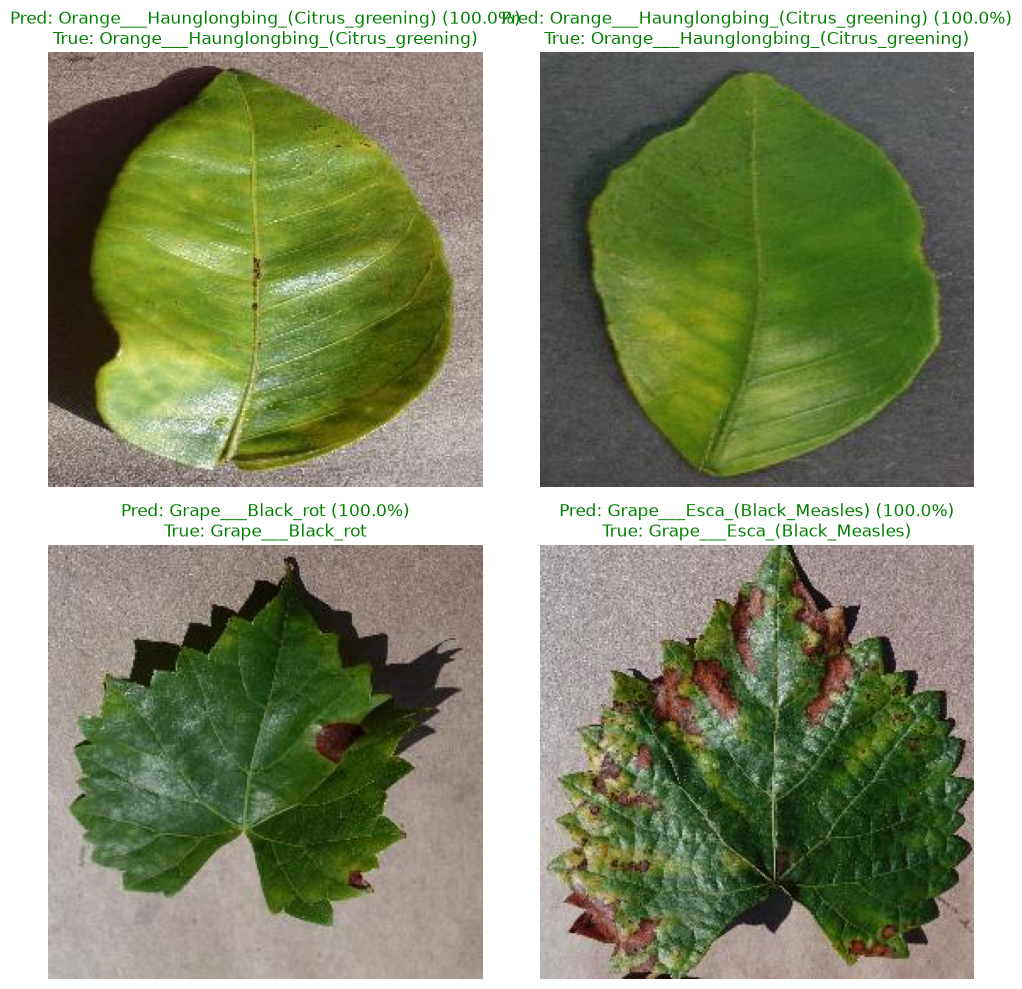

In [3]:
# Run prediction visual overlay
dataset = datasets.ImageFolder(str(utils.config.VAL_DIR))
class_names = dataset.classes

# Sample 4 random images
val_images = list(utils.config.VAL_DIR.glob("**/*.jpg")) + list(utils.config.VAL_DIR.glob("**/*.JPG"))

if val_images:
    sample_images = random.sample(val_images, min(4, len(val_images)))
    
    transform = transforms.Compose([
        transforms.Resize((utils.config.IMAGE_SIZE, utils.config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    model.eval()
    
    for idx, fpath in enumerate(sample_images):
        ax = axes[idx // 2, idx % 2]
        
        # Predict
        img_pil = Image.open(fpath).convert("RGB")
        input_tensor = transform(img_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(input_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            conf, pred_id = torch.max(probabilities, dim=1)
            
        # Extract labels
        predicted_class = class_names[pred_id.item()]
        true_class = fpath.parent.name
        
        ax.imshow(img_pil)
        ax.set_title(f"Pred: {predicted_class} ({conf.item()*100:.1f}%)\nTrue: {true_class}", 
                     color='green' if predicted_class == true_class else 'red')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("No validation images found.")